# 6. A joint fit to both charges

**Learning goals:** share CP parameters across charge models, generate charge yields consistently, and interpret a joint CP fit.

Run cells from top to bottom in a fresh Python kernel. Install the package and Jupyter
as explained in [the course guide](TUTORIALS.md). No external data files are needed.
Masses are in GeV, invariants in GeV², and daughter indices start at zero.
The small event counts and grid sizes keep this lesson practical on a CPU; they are
teaching settings, not a demonstrated precision choice for a physics analysis.

In [1]:
from dalitzplotfitter import enable_x64
enable_x64()  # Must precede numerical work: amplitudes use complex128.

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from dalitzplotfitter import (
    DecayChannel, DecayModel, FitSession, NonResonant,
    Parameter, RealImag, Resonance, generate_toy,
)

## Build the two charge amplitudes from shared parameters

`CPRealImag` uses `c_q = (x + q*dx) + i*(y + q*dy)`, with `q=+1` or `-1`.
Use the same parameter objects for both charges so the session collects them once.
We use an illustrative B -> K pi pi model, fixing the Kstar coefficient as reference.
The nonzero deltas below are toy inputs and not experimental measurements.

In [2]:
from dalitzplotfitter import CPRealImag, CPFitSession, generate_cp_toy
cp = CPRealImag(*[
    Parameter.coefficient(f"NR.{name}", value, owner="NR",
                          bounds=bounds, step=0.02)
    for name, value, bounds in [
        ("x", 0.8, (-2, 2)), ("y", 0.3, (-2, 2)),
        ("dx", 0.10, (-0.4, 0.4)), ("dy", -0.08, (-0.4, 0.4)),
    ]
])
def make_model(parent, daughters, charge):
    return DecayModel(
        DecayChannel(parent, daughters),
        [Resonance("Kstar", (0, 2), RealImag(1, 0),
                   mass=0.8958, width=0.0474, spin=1),
         NonResonant(cp.for_charge(charge), name="NR")],
        normalization_method="square-dalitz", normalization_pair=(0, 2),
        normalization_resolution=120,
    )

plus_model = make_model("B+", ("K+", "pi+", "pi-"), +1)
minus_model = make_model("B-", ("K-", "pi-", "pi+"), -1)
truth = {p.name: p.value for p in plus_model.parameters}
plus_data, minus_data = generate_cp_toy(
    plus_model, minus_model, 6000, parameters=truth, seed=61,
    inverse_resolution=512, include_momenta=False,
)
print("Charge counts:", plus_data.size, minus_data.size)
assert plus_data.size + minus_data.size == 6000

Charge counts: 3214 2786


## Fit charge as part of the sample space

The signal probabilities are `p(phi,q) = abs(A_q(phi))**2 / (I_plus + I_minus)`.
Consequently the relative charge counts carry information about the integrated asymmetry.
Generating fixed equal counts or normalizing each charge independently would describe a
different statistical problem. `generate_cp_toy` chooses the charge split from accepted
integrals; `CPFitSession` composes the matching `CPJointNLL`.

This example has no charge-dependent efficiency or production/detection nuisance terms.
A raw count asymmetry in experimental data is not automatically a physical CP asymmetry.

valid=True  NLL=29021.675910
parameter                           value            error
NR.x                             0.818053        0.0163044
NR.y                              0.28253         0.033432
NR.dx                           0.0839114        0.0143021
NR.dy                          0.00160581         0.033349
predicted charge fractions: B+=0.539348  B-=0.460652
B+ fit fractions
Fit fractions (physical)
component                    fraction [%]
Kstar                              52.791
NR                                 47.209
sum                               100.000

B- fit fractions
Fit fractions (physical)
component                    fraction [%]
Kstar                              61.809
NR                                 38.191
sum                               100.000
Unique fitted parameters: 4


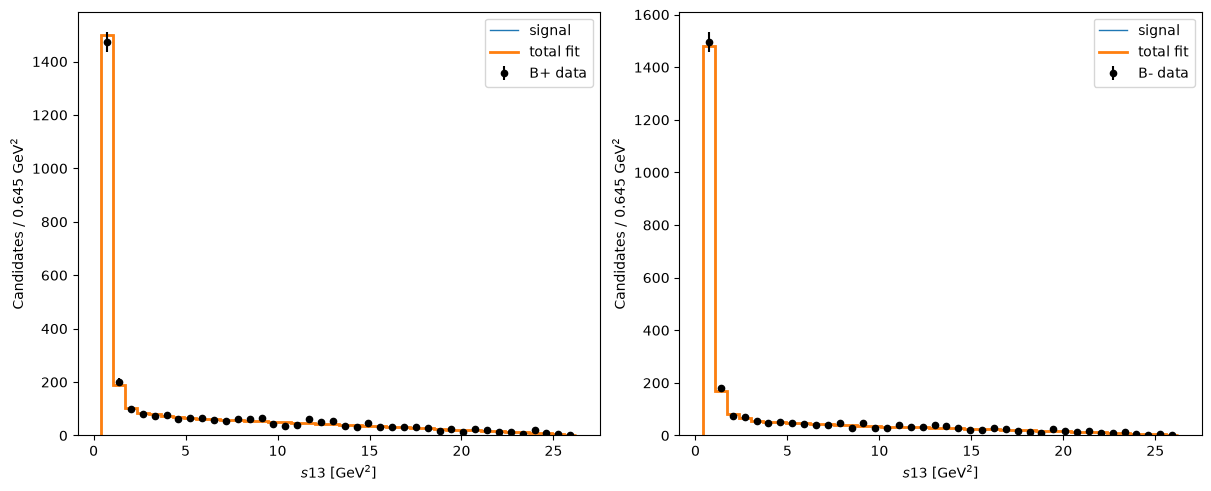

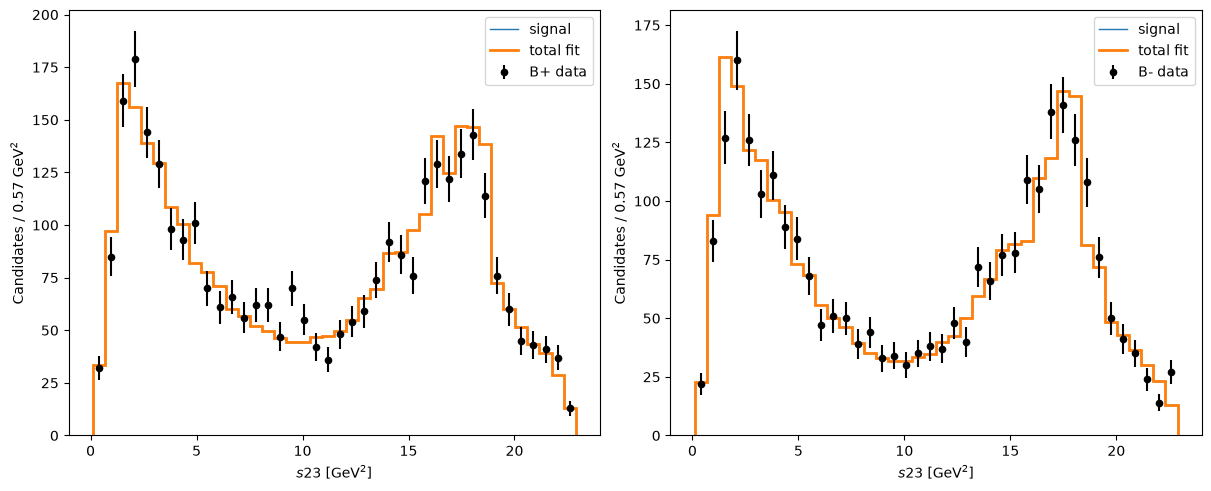

In [5]:
session = CPFitSession(plus_model, minus_model, plus_data, minus_data)
start = {name: value + 0.03 for name, value in truth.items()}
result = session.fit(start, simplex=True, ncall=10000)
session.report(result)
assert result.valid
print("Unique fitted parameters:", len(session.parameters))
assert len(session.parameters) == 4
session.plot_projection(result, "s13", bins=40, projection_size=250000)
session.plot_projection(result, "s23", bins=40, projection_size=250000)
plt.show()

Both panels retain a common charge normalization. The rendering sample sizes do not
set the physical charge yields. Nonzero `dx` or `dy` changes complex amplitudes; converting
that into a component or integrated CP asymmetry also involves the coefficient convention
and coherent integrals. Do not interpret a single delta divided by its error as a complete
CP-significance analysis.

## Try it yourself

1. Set both deltas to zero for generation and repeat the fit.
2. Inspect the charge counts and uncertainties across different seeds.
3. Read the CP documentation before adding charge-dependent efficiency or backgrounds.

## Continue learning

[Next: ROOT I/O](tutorial_07_root_io.ipynb). Reference: [CP conventions](../docs/cp_coefficients.md), [CP acceptance example](17_b2kpipi_cp_user_friendly.ipynb).

Return to [the course guide](TUTORIALS.md).